In [6]:
%matplotlib inline  

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from itertools import product as iproduct
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings("ignore")

In [7]:
SEED        = 25
PRED_LENGTH = 28
DATA_DIR    = "data"
os.makedirs(DATA_DIR, exist_ok=True)

cache = os.path.join(DATA_DIR, "raw_split.pkl")

if os.path.exists(cache):
    with open(cache, "rb") as f:
        d = pickle.load(f)
    print("Loaded cached data splits.")
else:
    base     = "https://huggingface.co/datasets/kashif/M5/resolve/main"
    sales    = pd.read_csv(f"{base}/sales_train_evaluation.csv")
    calendar = pd.read_csv(f"{base}/calendar.csv")
    prices   = pd.read_csv(f"{base}/sell_prices.csv")

    id_cols    = [c for c in sales.columns if not c.startswith("d_")]
    day_cols   = [c for c in sales.columns if c.startswith("d_")]
    sales_long = sales[id_cols + day_cols].melt(id_vars=id_cols, var_name="d", value_name="sales")
    sales_long["d_num"] = sales_long["d"].str[2:].astype(int)

    for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
        calendar[col] = calendar[col].fillna("none").astype("category")
    calendar["weekday"] = calendar["weekday"].astype("category")
    calendar["date"]    = pd.to_datetime(calendar["date"])
    for col in ["snap_CA", "snap_TX", "snap_WI", "wday", "month"]:
        calendar[col] = calendar[col].astype("int8")
    calendar["year"] = calendar["year"].astype("int16")
    sales_long = sales_long.merge(calendar, on="d", how="left")
    sales_long = sales_long.merge(
        prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]],
        on=["store_id", "item_id", "wm_yr_wk"], how="left"
    )
    sales_long["is_available"] = sales_long["sell_price"].notna().astype("int8")
    sales_long = sales_long.sort_values(["id", "d_num"]).reset_index(drop=True)
    sales_long["sell_price"] = (
        sales_long.groupby("id")["sell_price"]
        .transform(lambda x: x.ffill().fillna(0.0))
    )

    total_days = len(day_cols)
    train_end  = total_days - 6 * PRED_LENGTH   # 1773
    val_end    = total_days - 2 * PRED_LENGTH   # 1885

    train_raw = sales_long[sales_long["d_num"] <= train_end].reset_index(drop=True)
    val_raw   = sales_long[(sales_long["d_num"] > train_end) & (sales_long["d_num"] <= val_end)].reset_index(drop=True)

    last28       = train_raw[train_raw["d_num"] > train_end - 28]
    train_rev    = (last28["sales"] * last28["sell_price"]).groupby(last28["id"]).sum()
    item_weights = (train_rev / train_rev.sum()).rename("weight")

    d = dict(train_raw=train_raw, val_raw=val_raw, item_weights=item_weights)
    with open(cache, "wb") as f:
        pickle.dump(d, f)
    print("Cached data splits.")

train_raw    = d["train_raw"]
val_raw      = d["val_raw"]
item_weights = d["item_weights"]
train_end    = train_raw["d_num"].max()

# ── Sample 500 items ──────────────────────────────────────────────────────────
NUM_ITEMS   = 500
all_ids     = train_raw["id"].unique()
sampled_ids = np.random.default_rng(SEED).choice(all_ids, size=NUM_ITEMS, replace=False)

train_raw = train_raw[train_raw["id"].isin(sampled_ids)].reset_index(drop=True)
val_raw   = val_raw[val_raw["id"].isin(sampled_ids)].reset_index(drop=True)

print(f"Using {NUM_ITEMS} items")
print(f"Train: {len(train_raw):,} rows | Val: {len(val_raw):,} rows")

Loaded cached data splits.
Using 500 items
Train: 886,500 rows | Val: 56,000 rows


In [8]:
CAT_COLS = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2",
]

def encode_cats(df):
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category").cat.codes.astype("int16")
    return df

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["id", "d_num"]).reset_index(drop=True)

    # Lags
    for lag in [7, 28]:
        df[f"lag_{lag}"] = df.groupby("id")["sales"].shift(lag)

    # Rolling mean / std on lag_7
    g = df.groupby("id")["lag_7"]
    for w in [7, 28]:
        df[f"rmean_{w}"] = g.transform(lambda x, w=w: x.rolling(w, min_periods=1).mean()).astype("float32")
        df[f"rstd_{w}"]  = g.transform(lambda x, w=w: x.rolling(w, min_periods=1).std().fillna(0)).astype("float32")

    # Price momentum:  current price vs 28-day average price
    # Whether the item is currently on promotion or above its usual price. A ratio > 1 means price increase, < 1 means discount. 
    # Discounts typically spike demand, so this is an important signal.
    df["price_roll28"]   = df.groupby("id")["sell_price"].transform(lambda x: x.rolling(28, min_periods=1).mean()).astype("float32")
    df["price_momentum"] = (df["sell_price"] / (df["price_roll28"] + 1e-8)).astype("float32")

    # Calendar
    df["wday_sin"] = np.sin(2 * np.pi * df["wday"] / 7).astype("float32")
    df["wday_cos"] = np.cos(2 * np.pi * df["wday"] / 7).astype("float32")
    df["has_event"] = (
        (df["event_name_1"] != "none") | (df["event_name_2"] != "none")
    ).astype("int8")

    df = encode_cats(df)
    df = df.dropna(subset=["lag_7", "lag_28"]).reset_index(drop=True)
    return df

# Concatenate before building so val lags are correct
print("Building features ...")
combined      = pd.concat([train_raw, val_raw], ignore_index=True)
combined_feat = build_features(combined)

train_feat = combined_feat[combined_feat["d_num"] <= train_end].reset_index(drop=True)
val_feat   = combined_feat[combined_feat["d_num"] >  train_end].reset_index(drop=True)

EXCLUDE      = {"id", "d", "d_num", "sales", "date", "wm_yr_wk", "price_roll28"}
ALL_FEATURES = [c for c in combined_feat.columns if c not in EXCLUDE]

X_train   = train_feat[ALL_FEATURES].values.astype("float32")
y_train   = train_feat["sales"].values.astype("float32")
w_train   = item_weights.reindex(train_feat["id"]).fillna(0).values.astype("float32")
ids_train = train_feat["id"].values

X_val   = val_feat[ALL_FEATURES].values.astype("float32")
y_val   = val_feat["sales"].values.astype("float32")
ids_val = val_feat["id"].values

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")

Building features ...
Train: (872500, 28) | Val: (56000, 28)
Features (28): ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'is_available', 'lag_7', 'lag_28', 'rmean_7', 'rstd_7', 'rmean_28', 'rstd_28', 'price_momentum', 'wday_sin', 'wday_cos', 'has_event']


In [9]:
def compute_item_scales(train_raw):
    train_s = train_raw.sort_values(["id", "d_num"]).copy()
    train_s["prev"] = train_s.groupby("id")["sales"].shift(1)
    return (
        train_s.dropna(subset=["prev"])
        .assign(abs_diff=lambda df: (df["sales"] - df["prev"]).abs())
        .groupby("id")["abs_diff"].mean()
        .clip(lower=1e-8)
    )

def weighted_scaled_pinball_loss(y_true, y_pred, sample_ids, item_scales, item_weights, q=0.5):
    err      = y_true - y_pred
    pinball  = np.maximum(q * err, (q - 1) * err)
    df       = pd.DataFrame({"id": sample_ids, "pinball": pinball})
    per_item = df.groupby("id")["pinball"].mean()
    scale    = item_scales.reindex(per_item.index).fillna(1e-8)
    weights  = item_weights.reindex(per_item.index).fillna(0)
    return float(np.dot(weights.values, per_item.values / scale.values))

item_scales = compute_item_scales(train_raw)
print("Item scales computed.")

Item scales computed.


In [10]:
lgb_train_ds = lgb.Dataset(X_train, y_train, weight=w_train, feature_name=ALL_FEATURES)

param_grid = {
    "learning_rate": [0.05, 0.02, 0.01],
    "num_leaves"   : [63, 127],
}
base_params = {
    "objective": "quantile", "metric": "quantile",
    "alpha": 0.5, "reg_alpha": 0.1, "reg_lambda": 0.1,
    "n_jobs": -1, "verbose": -1,
}
keys   = list(param_grid.keys())
combos = list(iproduct(*param_grid.values()))

best_loss, best_params, results = float("inf"), None, []

print(f"Tuning ({len(combos)} trials) ...")
for combo in combos:
    candidate = {**base_params, **dict(zip(keys, combo))}
    booster   = lgb.train(
        candidate, lgb_train_ds,
        num_boost_round=200,
        valid_sets=[lgb.Dataset(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(50)],
    )
    preds = booster.predict(X_val)
    loss  = weighted_scaled_pinball_loss(y_val, preds, ids_val, item_scales, item_weights, q=0.5)
    results.append({**dict(zip(keys, combo)), "val_wspl": round(loss, 6)})
    print(f"  lr={combo[0]}  leaves={combo[1]}  →  wspl={loss:.5f}")
    if loss < best_loss:
        best_loss   = loss
        best_params = {k: v for k, v in candidate.items() if k != "alpha"}

print(f"\n✅ Best WSPL: {best_loss:.5f}")
print(f"   Best params: {best_params}")
tuning_df = pd.DataFrame(results).sort_values("val_wspl")
tuning_df

Tuning (6 trials) ...
[50]	valid_0's quantile: 0.489239
[100]	valid_0's quantile: 0.483927
  lr=0.05  leaves=63  →  wspl=0.01442
[50]	valid_0's quantile: 0.489239
[100]	valid_0's quantile: 0.483927
  lr=0.05  leaves=127  →  wspl=0.01442
[50]	valid_0's quantile: 0.541889
[100]	valid_0's quantile: 0.495669
[150]	valid_0's quantile: 0.486316
[200]	valid_0's quantile: 0.484239
  lr=0.02  leaves=63  →  wspl=0.01446
[50]	valid_0's quantile: 0.541889
[100]	valid_0's quantile: 0.495669
[150]	valid_0's quantile: 0.486316
[200]	valid_0's quantile: 0.484239
  lr=0.02  leaves=127  →  wspl=0.01446
[50]	valid_0's quantile: 0.59833
[100]	valid_0's quantile: 0.542075
[150]	valid_0's quantile: 0.511039
[200]	valid_0's quantile: 0.495555
  lr=0.01  leaves=63  →  wspl=0.01530
[50]	valid_0's quantile: 0.59833
[100]	valid_0's quantile: 0.542075
[150]	valid_0's quantile: 0.511039
[200]	valid_0's quantile: 0.495555
  lr=0.01  leaves=127  →  wspl=0.01530

✅ Best WSPL: 0.01442
   Best params: {'objective': 'qu

,learning_rate,num_leaves,val_wspl
0,0.05,63,0.014424
1,0.05,127,0.014424
2,0.02,63,0.014460
3,0.02,127,0.014460
4,0.01,63,0.015302
5,0.01,127,0.015302


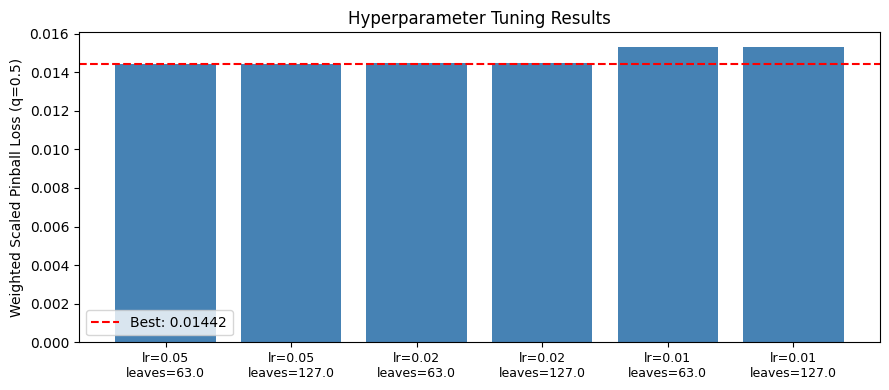

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"lr={r['learning_rate']}\nleaves={r['num_leaves']}" for _, r in tuning_df.iterrows()]
ax.bar(range(len(tuning_df)), tuning_df["val_wspl"].values, color="steelblue")
ax.axhline(tuning_df["val_wspl"].min(), color="red", linestyle="--",
           label=f"Best: {tuning_df['val_wspl'].min():.5f}")
ax.set_xticks(range(len(tuning_df)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Weighted Scaled Pinball Loss (q=0.5)")
ax.set_title("Hyperparameter Tuning Results")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
print("Training LightGBM models for all quantiles ...")
QUANTILES = [0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975]
lgbm_models = {}

for q in QUANTILES:
    print(f"   quantile {q} ...")
    lgbm_models[q] = lgb.train(
        {**best_params, "objective": "quantile", "alpha": q, "verbose": -1,
         "num_leaves": 127},
        lgb.Dataset(X_train, y_train, weight=w_train, feature_name=ALL_FEATURES),
        num_boost_round=500,
    )
print("Done.")

Training LightGBM models for all quantiles ...
   quantile 0.025 ...
   quantile 0.05 ...
   quantile 0.1 ...
   quantile 0.25 ...
   quantile 0.5 ...
   quantile 0.75 ...
   quantile 0.9 ...
   quantile 0.95 ...
   quantile 0.975 ...
Done.


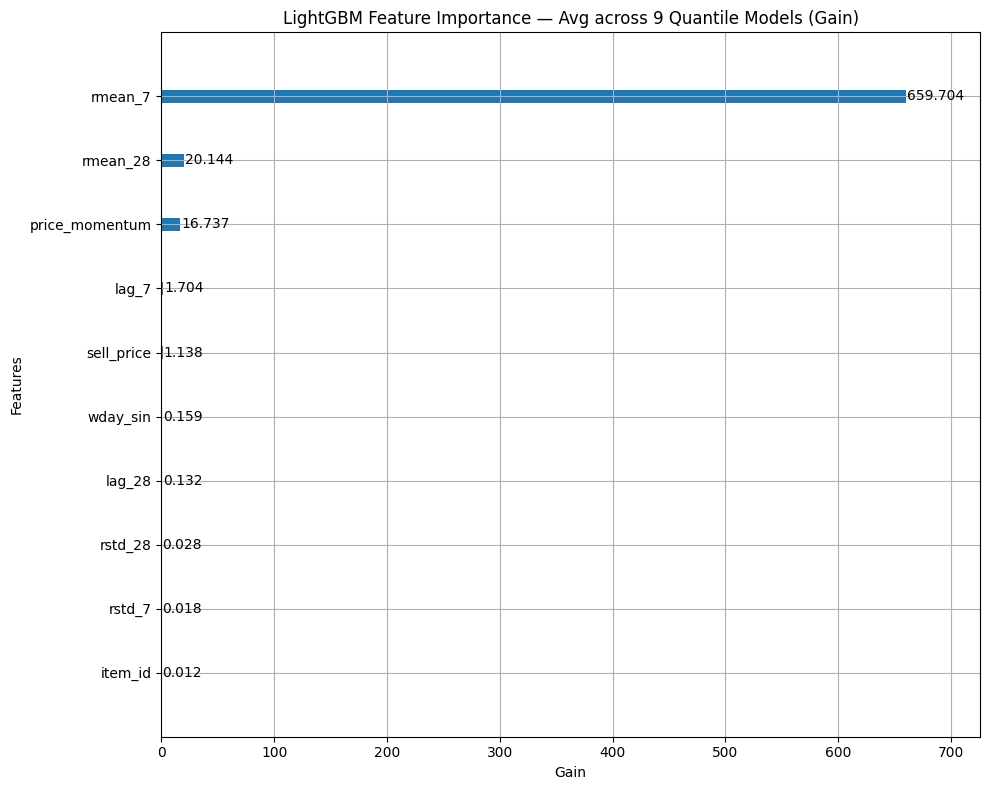

In [21]:
# Average gain importance across all 9 quantile models
avg_imp = np.zeros(len(ALL_FEATURES))
for booster in lgbm_models.values():
    avg_imp += booster.feature_importance(importance_type="gain")
avg_imp /= len(lgbm_models)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(
    lgbm_models[0.5],          # use median model for the built-in plot
    ax=ax,
    max_num_features=20,
    importance_type="gain",
    title="LightGBM Feature Importance — Avg across 9 Quantile Models (Gain)",
    xlabel="Gain",
)
plt.tight_layout()
plt.show()

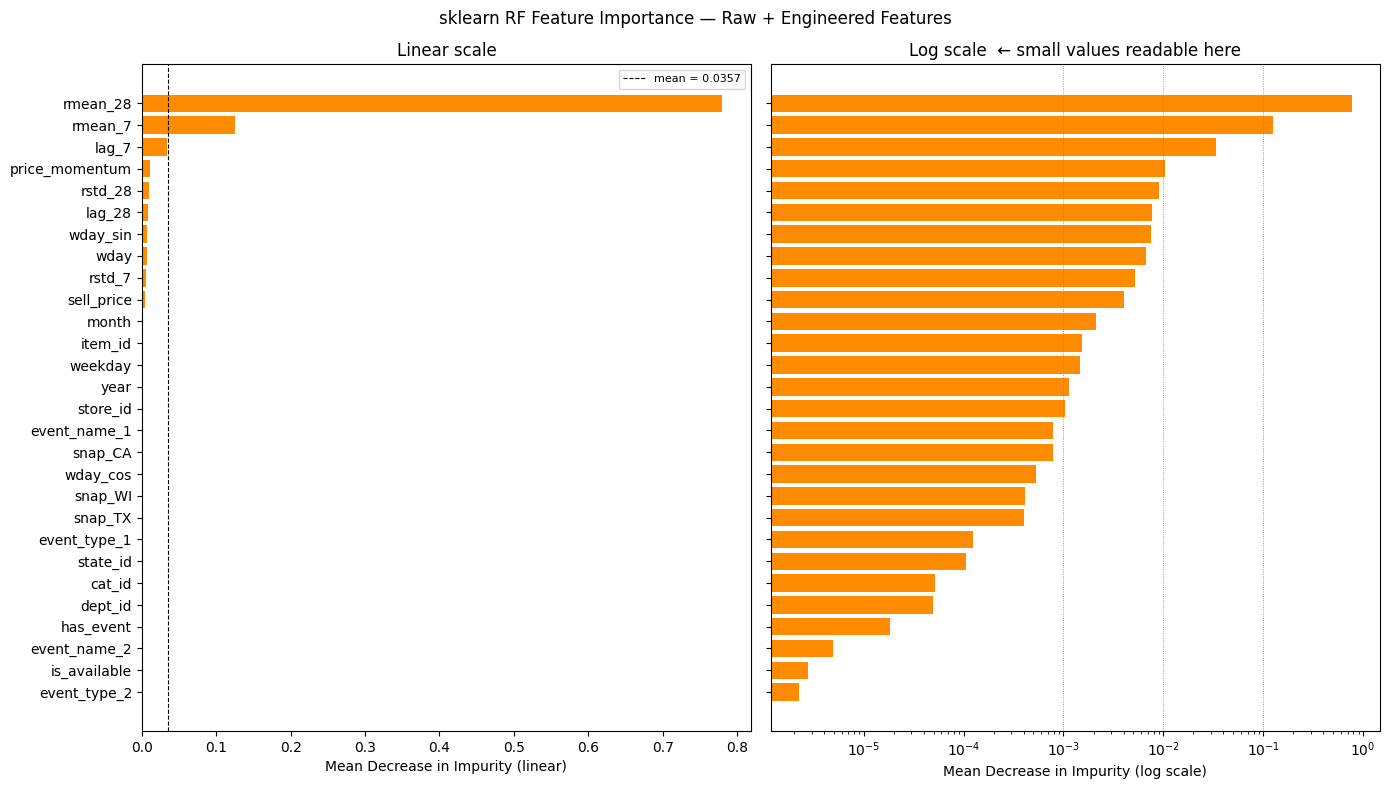

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

sorted_idx = np.argsort(rf.feature_importances_)
feats = [ALL_FEATURES[i] for i in sorted_idx]
imps  = rf.feature_importances_[sorted_idx]

# Linear
ax1.barh(feats, imps, color="darkorange", edgecolor="none")
ax1.set_xlabel("Mean Decrease in Impurity (linear)")
ax1.set_title("Linear scale")
ax1.axvline(imps.mean(), color="black", linestyle="--", linewidth=0.8,
            label=f"mean = {imps.mean():.4f}")
ax1.legend(fontsize=8)

# Log
ax2.barh(feats, imps, color="darkorange", edgecolor="none")
ax2.set_xscale("log")
ax2.set_xlabel("Mean Decrease in Impurity (log scale)")
ax2.set_title("Log scale  ← small values readable here")
for ref in [1e-3, 1e-2, 1e-1]:
    ax2.axvline(ref, color="grey", linestyle=":", linewidth=0.6)

plt.suptitle("sklearn RF Feature Importance — Raw + Engineered Features", fontsize=12)
plt.tight_layout()
plt.show()